# Plot weather station data

In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

%matplotlib widget

### Parameters

Specify the path to the data folder and the name of the weather data file:

In [2]:
weather_path = '../data/Meteo/Station/20260521/Level2/L2_meteo_netatmo_netatmo_taney.nc'

ds = xr.open_dataset(weather_path)
print(ds)

# Note: the "Pressure Pa" column is actually in hPa (values ~1000-1030),
# the CSV header is mislabeled. Multiply by 100 if you ever need pascals.

<xarray.Dataset> Size: 91kB
Dimensions:          (time: 598)
Coordinates:
  * time             (time) datetime64[ns] 5kB 2024-10-01T10:00:00 ... 2026-0...
    serial_id        <U13 52B ...
Data variables: (12/18)
    RH               (time) float64 5kB ...
    CO2              (time) float64 5kB ...
    pres             (time) float64 5kB ...
    wind_dir         (time) float64 5kB ...
    wind_speed       (time) float64 5kB ...
    gust_speed       (time) float64 5kB ...
    ...               ...
    CO2_qual         (time) int64 5kB ...
    wind_speed_qual  (time) int64 5kB ...
    wind_dir_qual    (time) int64 5kB ...
    gust_speed_qual  (time) int64 5kB ...
    gust_dir_qual    (time) int64 5kB ...
    rain_qual        (time) int64 5kB ...
Attributes: (12/18)
    xsc:             553319
    ysc:             132871
    altitude:        1417
    deployment:      2024-10-01 12:00:00
    retrieval:       2026-05-21 12:00:00
    sensor:          netatmo
    ...              ...
    sou

### Load the weather data

The CSV comes from a personal weather station (e.g. Netatmo). The `Timestamp`
column is Unix time in seconds (UTC); we convert it to a datetime column and
rename the messy headers to clean names.

In [3]:

df = ds.to_dataframe().reset_index()

# Colonnes par POSITION :
# 0 date | 1 RH | 2 CO2 | 3 Pression(hPa) | 4 dir vent | 5 vent |
# 6 rafale | 7 dir rafale | 8 Température | 9 Pluie  (reste = bloc Min/Max/Mean à ignorer)
cols = {
    0: 'date_str',
    1: 'RH_pct',
    2: 'CO2_ppm',
    3: 'P_hPa',            
    4: 'wind_dir_deg',
    5: 'wind_speed_kmph',
    6: 'gust_speed_kmph',
    7: 'gust_dir_deg',
    8: 'T_air_C',
    9: 'rain_mm',
}
df = df.iloc[:, list(cols.keys())]
df.columns = list(cols.values())

df = df[df['date_str'].notna()].copy()

local = pd.to_datetime(df['date_str'], format='%d/%m/%Y %H:%M')
df['UTC_time'] = (local
    .dt.tz_localize('Europe/Zurich', nonexistent='shift_forward', ambiguous='NaT')
    .dt.tz_convert('UTC'))

num_cols = ['RH_pct', 'CO2_ppm', 'P_hPa', 'wind_dir_deg', 'wind_speed_kmph',
            'gust_speed_kmph', 'gust_dir_deg', 'T_air_C', 'rain_mm']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

df = df.drop(columns='date_str').sort_values('UTC_time').reset_index(drop=True)

# On garde à partir du 1er juin 2025
df = df[df['UTC_time'] >= pd.Timestamp('2025-06-01', tz='UTC')].reset_index(drop=True)

time = df['UTC_time']
print(f"Rows: {len(df)}")
print(f"Period: {time.min()} to {time.max()} (UTC)")
df.head()

Rows: 355
Period: 2025-06-01 08:00:00+00:00 to 2026-05-21 08:00:00+00:00 (UTC)


,RH_pct,CO2_ppm,P_hPa,wind_dir_deg,wind_speed_kmph,gust_speed_kmph,gust_dir_deg,T_air_C,rain_mm,UTC_time
0,47.0,650.0,1023.2,139.0,2.0,21.0,230.0,14.2,10.9,2025-06-01 08:00:00+00:00
1,45.0,564.0,1021.8,208.0,2.0,17.0,204.0,11.1,0.3,2025-06-02 08:00:00+00:00
2,45.0,614.0,1019.1,215.0,3.0,20.0,197.0,11.7,17.4,2025-06-03 08:00:00+00:00
3,48.0,815.0,1016.2,221.0,4.0,39.0,248.0,10.6,3.7,2025-06-04 08:00:00+00:00
4,47.0,964.0,1018.3,206.0,2.0,20.0,233.0,10.5,3.1,2025-06-05 08:00:00+00:00


### 1. Time series of the main variables

Temperature, humidity, pressure, wind speed (with gusts) and rain.

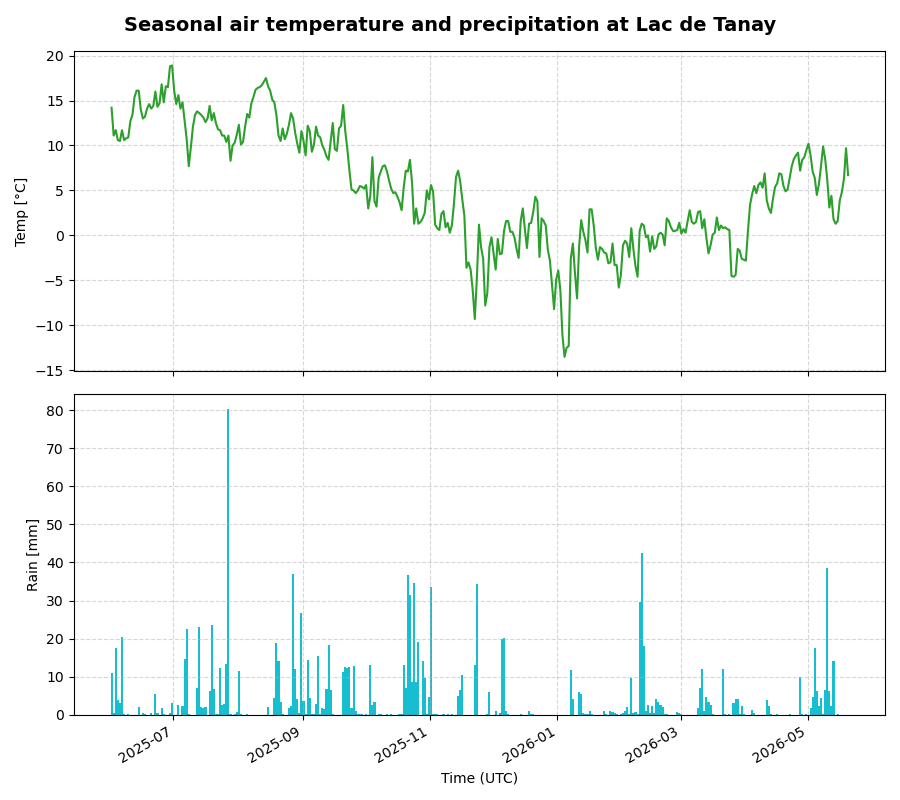

In [13]:
fig1, ax = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

fig1.suptitle('Seasonal air temperature and precipitation at Lac de Tanay', fontsize=14, fontweight='bold')

ax[0].plot(time, df['T_air_C'], color='tab:green')
ax[0].set_ylabel('Temp [°C]')

#ax[1].plot(time, df['RH_pct'], color='tab:blue')
#ax[1].set_ylabel('Humidity [%]')

#ax[2].plot(time, df['P_hPa'], color='tab:green')
#ax[2].set_ylabel('Pressure [hPa]')

#ax[3].plot(time, df['wind_speed_kmph'], color='tab:purple', label='Wind')
#ax[3].plot(time, df['gust_speed_kmph'], color='tab:orange', alpha=0.6, label='Gust')
#ax[3].set_ylabel('Wind [km/h]')
#ax[3].legend(loc='upper right')

ax[1].bar(time, df['rain_mm'], width=1.0, color='tab:cyan')
ax[1].set_ylabel('Rain [mm]')

ax[-1].set_xlabel('Time (UTC)')
ax[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig1.autofmt_xdate()
fig1.set_tight_layout(True)
for a in ax:
    a.grid(True, linestyle='--', alpha=0.5)



### 2. ICON model data (Level 2)

Données modèle ICON pour le lac Taney (fichier NetCDF `.nc`). On l'ouvre avec
**xarray**, on calcule la magnitude du vent `sqrt(U² + V²)` et on trace.
Le fichier n'a qu'une dimension `time` (la position est dans les attributs).

In [5]:
# Chemin du fichier ICON (adapte selon l'emplacement de ton .nc)
icon_path = '../data/Meteo/Model/20260604/Level2/L2_meteo_icon_icon_taney.nc'

ds = xr.open_dataset(icon_path)
print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:                (time: 8808)
Coordinates:
  * time                   (time) datetime64[ns] 70kB 2025-06-01 ... 2026-06-...
Data variables: (12/22)
    Temp_K                 (time) float64 70kB ...
    U                      (time) float64 70kB ...
    V                      (time) float64 70kB ...
    global_radiation       (time) float64 70kB ...
    RH                     (time) float64 70kB ...
    pres_Pa                (time) float64 70kB ...
    ...                     ...
    U_qual                 (time) int64 70kB ...
    V_qual                 (time) int64 70kB ...
    wind_speed_qual        (time) int64 70kB ...
    wind_dir_qual          (time) int64 70kB ...
    global_radiation_qual  (time) int64 70kB ...
    cloud_cover_qual       (time) int64 70kB ...
Attributes: (12/18)
    lon:             6.842092
    lat:             46.345857
    altitude:        
    deployment:      2025-06-01 00:00:00
    retrieval:       2026-06-03 23:00:0

Conversion en DataFrame (workflow habituel) et calcul du vent. Le `wind_speed`
déjà présent dans le fichier est identique à `sqrt(U² + V²)` — on recalcule
juste pour l'avoir explicitement.

In [6]:
icon = ds.to_dataframe().reset_index()
icon['time'] = pd.to_datetime(icon['time']).dt.tz_localize('UTC')
icon = icon.sort_values('time').reset_index(drop=True)
icon_time = icon['time']

# Magnitude du vent : sqrt(U^2 + V^2)  (U, V en m/s)
icon['wind_speed'] = np.sqrt(icon['U']**2 + icon['V']**2)   # m/s
icon['wind_speed_kmph'] = icon['wind_speed'] * 3.6          # km/h

print(f"Rows: {len(icon)}")
print(f"Period: {icon_time.min()} to {icon_time.max()} (UTC)")
icon[['time', 'U', 'V', 'wind_speed', 'wind_dir']].head()

Rows: 8808
Period: 2025-06-01 00:00:00+00:00 to 2026-06-03 23:00:00+00:00 (UTC)


,time,U,V,wind_speed,wind_dir
0,2025-06-01 00:00:00+00:00,3.317774,1.561525,3.666877,244.795769
1,2025-06-01 01:00:00+00:00,3.485481,1.383647,3.750074,248.348183
2,2025-06-01 02:00:00+00:00,3.611446,0.922924,3.727510,255.664579
3,2025-06-01 03:00:00+00:00,3.568264,0.377600,3.588188,263.959342
4,2025-06-01 04:00:00+00:00,3.214268,0.215132,3.221459,266.170877


Vitesse du vent ICON :

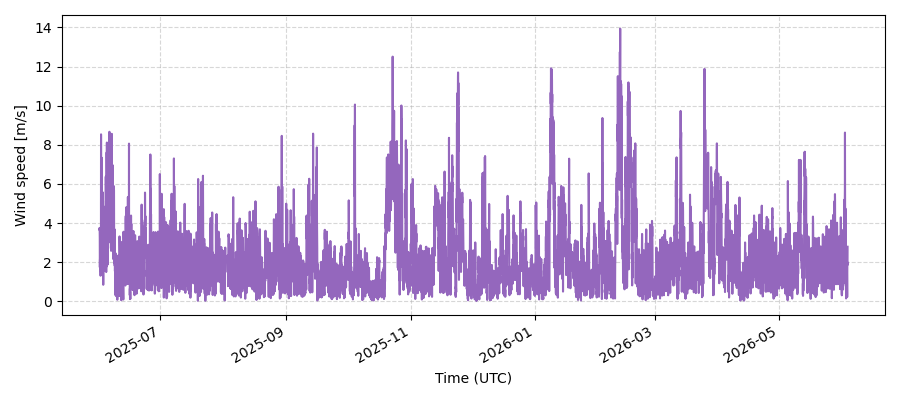

In [7]:
fig2, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.plot(icon_time, icon['wind_speed'], color='tab:purple')
ax.set_ylabel('Wind speed [m/s]')
ax.set_xlabel('Time (UTC)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig2.autofmt_xdate()
fig2.set_tight_layout(True)

Direction du vent ICON :

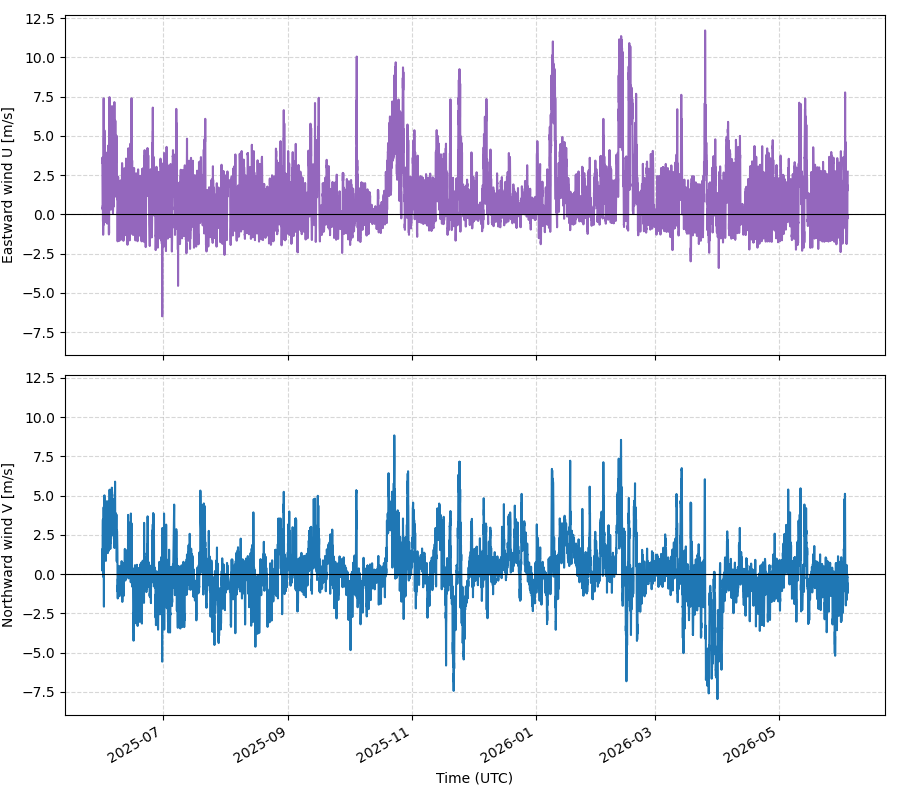

In [8]:
fig3, ax = plt.subplots(2, 1, figsize=(9, 8), sharex=True, sharey=True)

# Composante est (U)
ax[0].plot(icon_time, icon['U'], color='tab:purple')
ax[0].axhline(0, color='k', linewidth=0.8)
ax[0].set_ylabel('Eastward wind U [m/s]')

# Composante nord (V)
ax[1].plot(icon_time, icon['V'], color='tab:blue')
ax[1].axhline(0, color='k', linewidth=0.8)
ax[1].set_ylabel('Northward wind V [m/s]')

for a in ax:
    a.grid(True, linestyle='--', alpha=0.5)

ax[-1].set_xlabel('Time (UTC)')
ax[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig3.autofmt_xdate()
fig3.set_tight_layout(True)


In [9]:
#Min Max Mean

for col in ['U', 'V', 'wind_speed']:
    print(f"{col}: min={icon[col].min():.2f}, max={icon[col].max():.2f}, mean={icon[col].mean():.2f} m/s")

U: min=-6.49, max=11.72, mean=1.17 m/s
V: min=-7.96, max=8.84, mean=0.23 m/s
wind_speed: min=0.02, max=13.94, mean=2.33 m/s


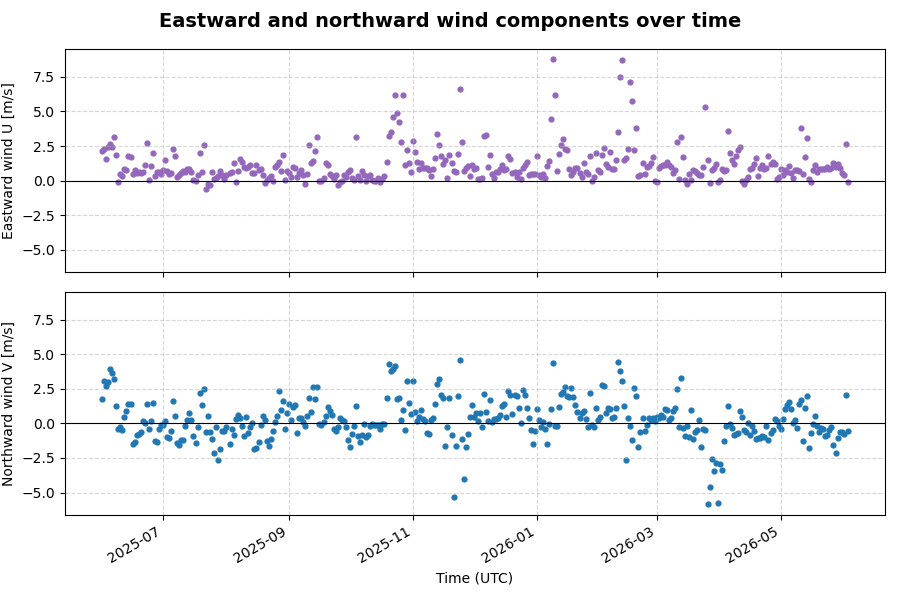

In [14]:
icon_daily = (icon.set_index('time')[['U', 'V', 'wind_speed']]
                  .resample('24h').mean()
                  .reset_index())

fig4, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True, sharey=True)
fig4.suptitle('Eastward and northward wind components over time', fontsize=14, fontweight='bold')

ax[0].scatter(icon_daily['time'], icon_daily['U'], s=12, color='tab:purple')
ax[0].axhline(0, color='k', linewidth=0.8)
ax[0].set_ylabel('Eastward wind U [m/s]')

ax[1].scatter(icon_daily['time'], icon_daily['V'], s=12, color='tab:blue')
ax[1].axhline(0, color='k', linewidth=0.8)
ax[1].set_ylabel('Northward wind V [m/s]')

for a in ax:
    a.grid(True, linestyle='--', alpha=0.5)

ax[-1].set_xlabel('Time (UTC)')
ax[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig4.autofmt_xdate()
fig4.set_tight_layout(True)

### Export the figures

In [11]:
os.makedirs("Figures", exist_ok=True)
fig1.savefig(os.path.join("Figures", "weather_time_series.png"), dpi=400)
fig2.savefig(os.path.join("Figures", "icon_wind_speed.png"), dpi=400)
fig3.savefig(os.path.join("Figures", "icon_wind_direction.png"), dpi=400)
fig4.savefig(os.path.join("Figures", "icon_wind_daily_average.png"), dpi=400)



In [16]:
# -------------------------------------------------------------------
# Summary statistics for weather station and ICON model data
# -------------------------------------------------------------------

def summary_statistics(data, variables, dataset_name):
    """
    Compute basic summary statistics for selected variables.
    Only variables present in the dataframe are used.
    """
    rows = []

    for col, unit in variables.items():
        if col in data.columns:
            s = pd.to_numeric(data[col], errors='coerce')

            rows.append({
                'dataset': dataset_name,
                'variable': col,
                'unit': unit,
                'n_values': s.count(),
                'n_missing': s.isna().sum(),
                'min': s.min(),
                'max': s.max(),
                'mean': s.mean(),
                'median': s.median(),
                'std': s.std()
            })

    return pd.DataFrame(rows)


# Variables from the local weather station
station_variables = {
    'T_air_C': '°C',
    'RH_pct': '%',
    'P_hPa': 'hPa',
    'wind_speed_kmph': 'km h⁻¹',
    'gust_speed_kmph': 'km h⁻¹',
    'rain_mm': 'mm',
    'CO2_ppm': 'ppm'
}

# Variables from the ICON model
icon_variables = {
    'U': 'm s⁻¹',
    'V': 'm s⁻¹',
    'wind_speed': 'm s⁻¹',
    'wind_speed_kmph': 'km h⁻¹'
}

station_stats = summary_statistics(df, station_variables, 'Local weather station')
icon_stats = summary_statistics(icon, icon_variables, 'ICON model')

weather_stats = pd.concat([station_stats, icon_stats], ignore_index=True)

# Round values for readability
weather_stats[['min', 'max', 'mean', 'median', 'std']] = weather_stats[
    ['min', 'max', 'mean', 'median', 'std']
].round(2)

display(weather_stats)

# Additional precipitation summary
if 'rain_mm' in df.columns:
    total_rain = df['rain_mm'].sum(skipna=True)
    print(f"Total rainfall over the station period: {total_rain:.2f} mm")

,dataset,variable,unit,n_values,n_missing,min,max,mean,median,std
0,Local weather station,T_air_C,°C,354,1,-13.50,18.90,5.11,4.70,6.49
1,Local weather station,RH_pct,%,355,0,26.00,54.00,42.25,43.00,5.47
2,Local weather station,P_hPa,hPa,355,0,986.90,1031.40,1016.41,1018.30,8.87
3,Local weather station,wind_speed_kmph,km h⁻¹,355,0,1.00,9.00,2.55,2.00,1.27
4,Local weather station,gust_speed_kmph,km h⁻¹,355,0,4.00,44.00,16.52,14.00,8.08
5,Local weather station,rain_mm,mm,349,6,0.00,80.30,3.64,0.10,8.31
6,Local weather station,CO2_ppm,ppm,355,0,388.00,1795.00,620.62,580.00,216.33
7,ICON model,U,m s⁻¹,8808,0,-6.49,11.72,1.17,0.91,1.95
8,ICON model,V,m s⁻¹,8808,0,-7.96,8.84,0.23,0.18,1.88
9,ICON model,wind_speed,m s⁻¹,8808,0,0.02,13.94,2.33,1.90,1.82


Total rainfall over the station period: 1271.70 mm
